# Inter-Node Analysis

This notebook loads a benchmark's capability tree and analyzes the differences between:

1. Model ranking on the full benchmark vs each node
2. Model performance on the full benchmark vs each node

Import packages.

In [336]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import kendalltau
from tqdm import tqdm
from src.utils.capability_tree import (
    align_rankings,
    collect_nodes,
    load_capability_tree,
)
from src.utils.enums import Dataset
from src.utils.path import build_plot_path
from src.utils.plot import plot_histogram

Specify the benchmark, load it's capability tree, and collect the tree's nodes.

In [337]:
dataset = Dataset.WILDCHAT_10K
root = load_capability_tree(dataset)

min_instances = 50
global_ranking = root["ranking"]
nodes = collect_nodes(root, min_instances)

num_models = len(global_ranking)
print(f"Number of models: {num_models}")
print(f"Found {len(nodes)} nodes (non-root, size > {min_instances} instances)")

Number of models: 2
Found 184 nodes (non-root, size > 50 instances)


### Model Ranking Analysis

Compute the Kendall's Tau between each node's local model ranking and the global model ranking.

In [338]:
taus = np.zeros(len(nodes))

kwargs = {
    "desc": "Computing Kendall's Taus",
    "total": len(nodes),
    "unit": "node",
}

for i, node in tqdm(enumerate(nodes), **kwargs):
    if node["ranking"] is None:
        continue
    aligned_global, aligned_local = align_rankings(
        global_ranking,
        node["ranking"],
    )
    tau, _ = kendalltau(aligned_global, aligned_local)
    taus[i] = tau

Computing Kendall's Taus: 100%|██████████| 184/184 [00:00<00:00, 4721.26node/s]


Plot a histogram of the Kendall's Taus bewteen each node's model ranking and the global model ranking.

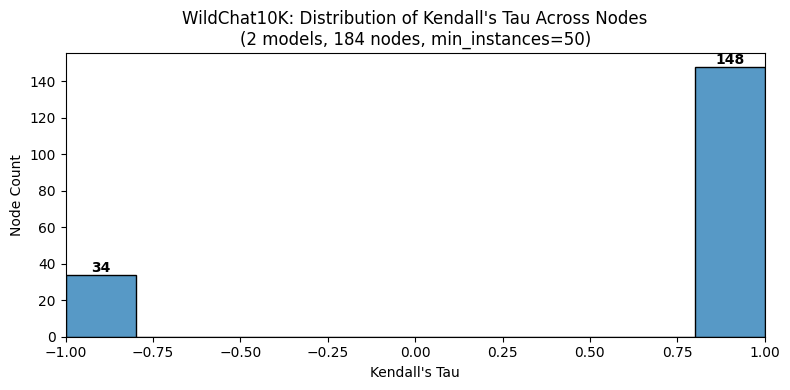

In [339]:
xlabel = "Kendall's Tau"
ylabel = "Node Count"
title = (
    f"{dataset}: Distribution of Kendall's Tau Across Nodes"
    f"\n({num_models} models, {len(nodes)} nodes, min_instances={min_instances})"
)
annotate = True
xlim = (-1, 1) if min(taus) < 0 else (0, 1)   

plot_histogram(
    taus,
    xlabel=xlabel,
    ylabel=ylabel,
    title=title,
    annotate=annotate,
    mean=taus.mean(),
    std=taus.std(),
    xlim=xlim,
)

analysis = "inter_node_analysis"
plot_name = f"kendall_tau_distribution-min_instances={min_instances}"
plot_path = build_plot_path(
    dataset,
    analysis=analysis,
    plot_name=plot_name,
)
plt.savefig(plot_path)
plt.show()